# Transformer Language Model on Tiny Shakespeare
**Assignment 4 — EAI6010: Applications of Artificial Intelligence**

This notebook trains a `nn.TransformerEncoder` language model on the **Tiny Shakespeare** dataset (~1.1MB of Shakespeare's plays) to perform next-word prediction and text generation.

**Original Tutorial:** [Language Modeling with nn.Transformer and torchtext](https://pytorch.org/tutorials/beginner/transformer_tutorial.html)  
**Dataset:** [Tiny Shakespeare (Karpathy)](https://huggingface.co/datasets/karpathy/tiny_shakespeare)  
**Adapted Dataset:** Tiny Shakespeare — 40,000 lines of Shakespeare from a variety of plays

## Cell 1: Imports

In [ ]:
import math
import os
import re
import time
import random
import requests
from collections import Counter
from tempfile import TemporaryDirectory
from typing import Tuple, List

import torch
from torch import nn, Tensor
from torch.nn import TransformerEncoder, TransformerEncoderLayer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Cell 2: Download Tiny Shakespeare

In [ ]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
raw_text = response.text

print(f"Total characters: {len(raw_text):,}")
print(f"Total lines: {len(raw_text.splitlines()):,}")
print(f"\nFirst 500 characters:\n{'='*50}")
print(raw_text[:500])

Total characters: 1,115,394
Total lines: 40,000

First 500 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## Cell 3: Train/Val/Test Split

Shakespeare's text file is organized play-by-play. A sequential split would put entirely different plays in test vs train, causing a distribution mismatch. We shuffle lines first to ensure all splits contain a mix of all plays.

In [ ]:
random.seed(42)

lines = raw_text.splitlines()

# Remove empty lines to avoid wasting tokens
lines = [line for line in lines if line.strip()]

# Shuffle so all plays are represented in every split
random.shuffle(lines)

total_lines = len(lines)
train_end = int(total_lines * 0.90)
val_end = int(total_lines * 0.95)

train_text = lines[:train_end]
val_text = lines[train_end:val_end]
test_text = lines[val_end:]

print(f"Total non-empty lines: {total_lines:,}")
print(f"Train lines: {len(train_text):,}")
print(f"Val lines:   {len(val_text):,}")
print(f"Test lines:  {len(test_text):,}")

print(f"\nSample train lines:")
for line in train_text[:3]:
    print(f"  {line[:80]}")
print(f"\nSample test lines:")
for line in test_text[:3]:
    print(f"  {line[:80]}")

Total non-empty lines: 32,777
Train lines: 29,499
Val lines:   1,639
Test lines:  1,639

Sample train lines:
  PARIS:
  Then, by myself--
  Ay, every dram of woman's flesh is false, If she be.

Sample test lines:
  When I perceive your grace, like power divine,
  And duty bids defend; the other again
  What, resists he? Help him, Lucio.


## Cell 4: Tokenizer & Vocabulary

We implement a `basic_english` tokenizer (lowercase + split punctuation) and a custom `Vocab` class that maps tokens to integer indices, sorted by frequency.

In [ ]:
def basic_english_tokenize(text: str) -> List[str]:
    """
    Tokenizer that lowercases text, pads punctuation with spaces,
    and splits on whitespace.
    """
    text = text.lower()
    text = re.sub(r'([.,!?;:\'\"\(\)\[\]\-])', r' \1 ', text)
    tokens = text.split()
    return tokens


class Vocab:
    """
    Minimal vocabulary class.
    Maps tokens to integer indices, sorted by frequency.
    Special tokens (like <unk>) are placed first.
    """

    def __init__(self, token_counts: Counter, specials: List[str] = None):
        self.itos = []
        self.stoi = {}
        self.default_index = 0

        if specials:
            for s in specials:
                self.stoi[s] = len(self.itos)
                self.itos.append(s)

        for token, _ in token_counts.most_common():
            if token not in self.stoi:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)

    def set_default_index(self, index: int):
        self.default_index = index

    def __len__(self):
        return len(self.itos)

    def __getitem__(self, token: str) -> int:
        return self.stoi.get(token, self.default_index)

    def __call__(self, tokens: List[str]) -> List[int]:
        return [self.stoi.get(t, self.default_index) for t in tokens]

    def get_itos(self) -> List[str]:
        return self.itos


def build_vocab_from_iterator(iterator, specials=None):
    """Scans all token lists, counts frequencies, builds Vocab."""
    counter = Counter()
    for tokens in iterator:
        counter.update(tokens)
    return Vocab(counter, specials=specials)


tokenizer = basic_english_tokenize

vocab = build_vocab_from_iterator(
    map(tokenizer, train_text),
    specials=['<unk>']
)
vocab.set_default_index(vocab['<unk>'])

print(f"Vocabulary size: {len(vocab):,}")

sample_tokens = ['romeo', 'juliet', 'thou', 'thee', 'hath', 'doth',
                 'wherefore', 'thy', 'lord', 'king']
print(f"\nShakespeare tokens in vocab:")
for token in sample_tokens:
    idx = vocab[token]
    status = "found" if idx != vocab['<unk>'] else "unknown"
    print(f"  '{token}' -> index {idx} ({status})")

print(f"\nTop 20 most frequent tokens:")
for i in range(1, 21):
    print(f"  {i:2d}. '{vocab.get_itos()[i]}'")

Vocabulary size: 10,926

Shakespeare tokens in vocab:
  'romeo' -> index 119 (found)
  'juliet' -> index 166 (found)
  'thou' -> index 34 (found)
  'thee' -> index 52 (found)
  'hath' -> index 81 (found)
  'doth' -> index 149 (found)
  'wherefore' -> index 847 (found)
  'thy' -> index 39 (found)
  'lord' -> index 54 (found)
  'king' -> index 45 (found)

Top 20 most frequent tokens:
   1. ','
   2. ':'
   3. '.'
   4. 'the'
   5. '''
   6. 'and'
   7. 'i'
   8. 'to'
   9. 'of'
  10. ';'
  11. 'you'
  12. 'my'
  13. 'a'
  14. 'that'
  15. '?'
  16. 'in'
  17. '!'
  18. 'is'
  19. 'not'
  20. 'for'


## Cell 5: Process Data into Tensors & Batchify

In [ ]:
def data_process(raw_text_iter) -> Tensor:
    """Converts raw text lines into a flat Tensor of token indices."""
    data = [torch.tensor(vocab(tokenizer(item)), dtype=torch.long)
            for item in raw_text_iter]
    return torch.cat(tuple(filter(lambda t: t.numel() > 0, data)))


train_data = data_process(train_text)
val_data = data_process(val_text)
test_data = data_process(test_text)

print(f"Train tokens: {len(train_data):,}")
print(f"Val tokens:   {len(val_data):,}")
print(f"Test tokens:  {len(test_data):,}")


def batchify(data: Tensor, bsz: int) -> Tensor:
    """Divides data into bsz separate sequences, removing extra elements."""
    seq_len = data.size(0) // bsz
    data = data[:seq_len * bsz]
    data = data.view(bsz, seq_len).t().contiguous()
    return data.to(device)


batch_size = 20
eval_batch_size = 10
train_data = batchify(train_data, batch_size)
val_data = batchify(val_data, eval_batch_size)
test_data = batchify(test_data, eval_batch_size)

print(f"\nAfter batchify:")
print(f"  train_data shape: {train_data.shape}")
print(f"  val_data shape:   {val_data.shape}")
print(f"  test_data shape:  {test_data.shape}")

Train tokens: 236,463
Val tokens:   13,215
Test tokens:  13,244

After batchify:
  train_data shape: torch.Size([11823, 20])
  val_data shape:   torch.Size([1321, 10])
  test_data shape:  torch.Size([1324, 10])


## Cell 6: Input/Target Sequence Generation

In [ ]:
bptt = 35

def get_batch(source: Tensor, i: int) -> Tuple[Tensor, Tensor]:
    """
    Extracts a chunk of data and its corresponding target.
    Target is the same chunk shifted by 1 position.
    """
    seq_len = min(bptt, len(source) - 1 - i)
    data = source[i:i+seq_len]
    target = source[i+1:i+1+seq_len].reshape(-1)
    return data, target


# Sanity check
sample_data, sample_target = get_batch(train_data, 0)
print(f"Sample batch — input shape: {sample_data.shape}, target shape: {sample_target.shape}")

sample_indices = sample_data[:10, 0].tolist()
sample_words = [vocab.get_itos()[idx] for idx in sample_indices]
print(f"First 10 tokens of first batch: {' '.join(sample_words)}")

Sample batch — input shape: torch.Size([35, 20]), target shape: torch.Size([700])
First 10 tokens of first batch: paris : then , by myself - - ay ,


## Cell 7: Positional Encoding

Injects position information into token embeddings using sine/cosine waves. Without this, the Transformer has no sense of word order.

In [ ]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x: Tensor) -> Tensor:
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)


print("PositionalEncoding class defined.")

PositionalEncoding class defined.


## Cell 8: Transformer Model

The full model: Embedding → Positional Encoding → TransformerEncoder (masked self-attention + FFN) → Linear output to vocabulary size.

In [ ]:
class TransformerModel(nn.Module):

    def __init__(self, ntoken: int, d_model: int, nhead: int, d_hid: int,
                 nlayers: int, dropout: float = 0.5):
        super().__init__()
        self.model_type = 'Transformer'
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layers = TransformerEncoderLayer(d_model, nhead, d_hid, dropout)
        self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)
        self.embedding = nn.Embedding(ntoken, d_model)
        self.d_model = d_model
        self.linear = nn.Linear(d_model, ntoken)

        self.init_weights()

    def init_weights(self) -> None:
        initrange = 0.1
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.linear.bias.data.zero_()
        self.linear.weight.data.uniform_(-initrange, initrange)

    def forward(self, src: Tensor, src_mask: Tensor = None) -> Tensor:
        src = self.embedding(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src, src_mask)
        output = self.linear(output)
        return output


def generate_square_subsequent_mask(sz: int) -> Tensor:
    """Generates causal mask: upper-triangular -inf matrix."""
    mask = torch.triu(torch.ones(sz, sz) * float('-inf'), diagonal=1)
    return mask


print("TransformerModel class defined.")
print("generate_square_subsequent_mask() function defined.")

TransformerModel class defined.
generate_square_subsequent_mask() function defined.


## Cell 9: Hyperparameters & Model Instantiation

Dropout increased from 0.2 to 0.3 to combat overfitting on the smaller Shakespeare dataset.

In [ ]:
ntokens = len(vocab)
emsize = 200
d_hid = 200
nlayers = 2
nhead = 2
dropout = 0.3

model = TransformerModel(ntokens, emsize, nhead, d_hid, nlayers, dropout).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model hyperparameters:")
print(f"  Vocab size (ntokens): {ntokens:,}")
print(f"  Embedding dim:        {emsize}")
print(f"  FFN hidden dim:       {d_hid}")
print(f"  Encoder layers:       {nlayers}")
print(f"  Attention heads:      {nhead}")
print(f"  Head dimension:       {emsize // nhead}")
print(f"  Dropout:              {dropout}")
print(f"\nModel size:")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Approx memory:        {total_params * 4 / 1024 / 1024:.1f} MB (float32)")
print(f"\nModel architecture:")
print(model)

Model hyperparameters:
  Vocab size (ntokens): 10,926
  Embedding dim:        200
  FFN hidden dim:       200
  Encoder layers:       2
  Attention heads:      2
  Head dimension:       100
  Dropout:              0.3

Model size:
  Total parameters:     4,865,326
  Trainable parameters: 4,865,326
  Approx memory:        18.6 MB (float32)

Model architecture:
TransformerModel(
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=200, out_features=200, bias=True)
        )
        (linear1): Linear(in_features=200, out_features=200, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=200, out_features=200, bias=True)
        (norm1): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
      

/tmp/ipykernel_4160/1164051776.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)


## Cell 10: Training & Evaluation Functions

In [ ]:
criterion = nn.CrossEntropyLoss()
lr = 5.0
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)

print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer:     SGD (lr={lr})")
print(f"Scheduler:     StepLR (gamma=0.95)")
print(f"Grad clipping: max norm 0.5")


def train(model: nn.Module) -> None:
    model.train()
    total_loss = 0.
    log_interval = 200
    start_time = time.time()

    src_mask = generate_square_subsequent_mask(bptt).to(device)
    num_batches = len(train_data) // bptt

    for batch, i in enumerate(range(0, train_data.size(0) - 1, bptt)):
        data, targets = get_batch(train_data, i)
        seq_len = data.size(0)

        if seq_len != bptt:
            src_mask = generate_square_subsequent_mask(seq_len).to(device)

        output = model(data, src_mask)
        output_flat = output.view(-1, ntokens)
        loss = criterion(output_flat, targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        total_loss += loss.item()

        if batch % log_interval == 0 and batch > 0:
            lr = scheduler.get_last_lr()[0]
            ms_per_batch = (time.time() - start_time) * 1000 / log_interval
            cur_loss = total_loss / log_interval
            ppl = math.exp(cur_loss)
            print(f'| epoch {epoch:3d} | {batch:5d}/{num_batches:5d} batches | '
                  f'lr {lr:02.2f} | ms/batch {ms_per_batch:5.2f} | '
                  f'loss {cur_loss:5.2f} | ppl {ppl:8.2f}')
            total_loss = 0
            start_time = time.time()


def evaluate(model: nn.Module, eval_data: Tensor) -> float:
    model.eval()
    total_loss = 0.
    src_mask = generate_square_subsequent_mask(bptt).to(device)

    with torch.no_grad():
        for i in range(0, eval_data.size(0) - 1, bptt):
            data, targets = get_batch(eval_data, i)
            seq_len = data.size(0)

            if seq_len != bptt:
                src_mask = generate_square_subsequent_mask(seq_len).to(device)

            output = model(data, src_mask)
            output_flat = output.view(-1, ntokens)
            total_loss += seq_len * criterion(output_flat, targets).item()

    return total_loss / (len(eval_data) - 1)


print("\ntrain() and evaluate() functions defined.")

Loss function: CrossEntropyLoss
Optimizer:     SGD (lr=5.0)
Scheduler:     StepLR (gamma=0.95)
Grad clipping: max norm 0.5

train() and evaluate() functions defined.


## Cell 11: Training Loop (10 epochs)

In [ ]:
best_val_loss = float('inf')
epochs = 10

train_losses = []
val_losses = []

total_train_start = time.time()

with TemporaryDirectory() as tempdir:
    best_model_params_path = os.path.join(tempdir, "best_model_params.pt")

    for epoch in range(1, epochs + 1):
        epoch_start_time = time.time()

        train(model)

        val_loss = evaluate(model, val_data)
        val_ppl = math.exp(val_loss)
        elapsed = time.time() - epoch_start_time

        train_loss = evaluate(model, train_data)
        train_ppl = math.exp(train_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print('-' * 89)
        print(f'| end of epoch {epoch:3d} | time: {elapsed:5.2f}s | '
              f'train loss {train_loss:5.2f} | train ppl {train_ppl:8.2f}')
        print(f'|                  | '
              f'valid loss {val_loss:5.2f} | valid ppl {val_ppl:8.2f}')
        print('-' * 89)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_params_path)
            print(f'  New best model saved! (val loss: {val_loss:.2f})')

        scheduler.step()

    model.load_state_dict(torch.load(best_model_params_path))

total_train_time = time.time() - total_train_start
print(f'\nTotal training time: {total_train_time:.1f}s ({total_train_time/60:.1f} min)')
print(f'Best validation loss: {best_val_loss:.2f} (ppl: {math.exp(best_val_loss):.2f})')

| epoch   1 |   200/  337 batches | lr 5.00 | ms/batch 10.69 | loss  7.04 | ppl  1143.00
-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  3.11s | train loss  5.73 | train ppl   308.28
|                  | valid loss  5.78 | valid ppl   323.87
-----------------------------------------------------------------------------------------
  New best model saved! (val loss: 5.78)
| epoch   2 |   200/  337 batches | lr 4.75 | ms/batch  7.40 | loss  5.67 | ppl   289.34
-----------------------------------------------------------------------------------------
| end of epoch   2 | time:  2.45s | train loss  5.36 | train ppl   211.87
|                  | valid loss  5.49 | valid ppl   243.42
-----------------------------------------------------------------------------------------
  New best model saved! (val loss: 5.49)
| epoch   3 |   200/  337 batches | lr 4.51 | ms/batch  7.06 | loss  5.43 | ppl   228.86
-------------------------

## Training Loss Visualization

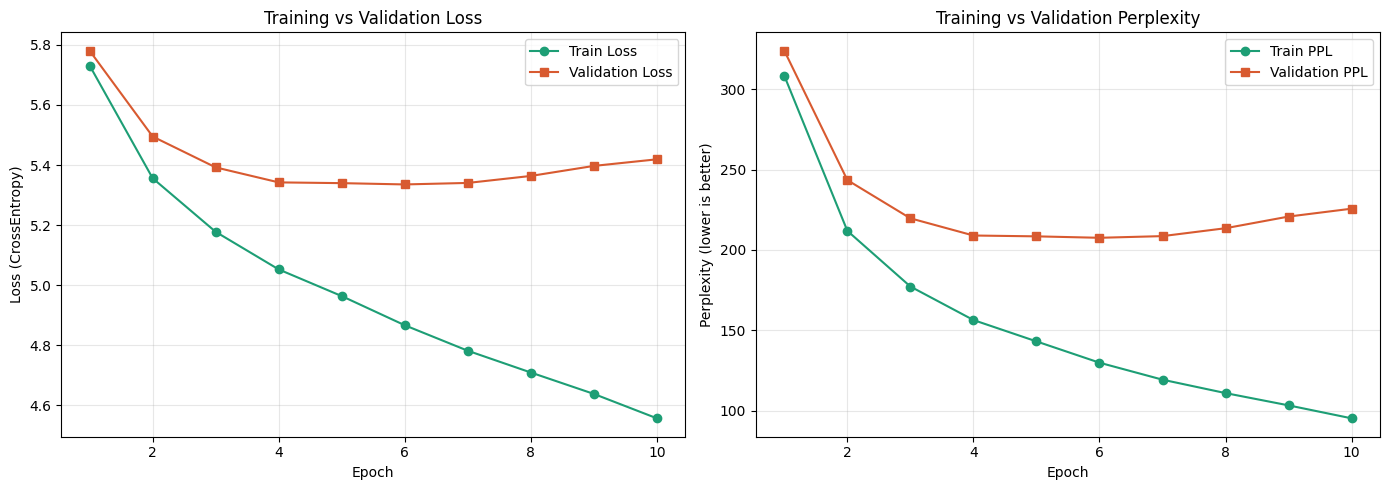


Overfitting analysis:
  Final train loss:      4.56 (ppl: 95.31)
  Final validation loss: 5.42 (ppl: 225.66)
  Gap: 0.86
  Moderate overfitting. Model is learning but not generalizing perfectly.


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs + 1), train_losses, 'o-', label='Train Loss', color='#1D9E75')
ax1.plot(range(1, epochs + 1), val_losses, 's-', label='Validation Loss', color='#D85A30')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (CrossEntropy)')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

train_ppls = [math.exp(l) for l in train_losses]
val_ppls = [math.exp(l) for l in val_losses]
ax2.plot(range(1, epochs + 1), train_ppls, 'o-', label='Train PPL', color='#1D9E75')
ax2.plot(range(1, epochs + 1), val_ppls, 's-', label='Validation PPL', color='#D85A30')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity (lower is better)')
ax2.set_title('Training vs Validation Perplexity')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

gap = val_losses[-1] - train_losses[-1]
print(f"\nOverfitting analysis:")
print(f"  Final train loss:      {train_losses[-1]:.2f} (ppl: {train_ppls[-1]:.2f})")
print(f"  Final validation loss: {val_losses[-1]:.2f} (ppl: {val_ppls[-1]:.2f})")
print(f"  Gap: {gap:.2f}")
if gap > 1.0:
    print(f"  Warning: Significant overfitting detected.")
elif gap > 0.5:
    print(f"  Moderate overfitting. Model is learning but not generalizing perfectly.")
else:
    print(f"  Minimal overfitting. Model is generalizing well.")

## Cell 12: Test Set Evaluation

In [ ]:
test_loss = evaluate(model, test_data)
test_ppl = math.exp(test_loss)

print('=' * 89)
print(f'| End of training | test loss {test_loss:5.2f} | test ppl {test_ppl:8.2f}')
print('=' * 89)

print(f"\n{'='*60}")
print(f"  RESULTS SUMMARY")
print(f"{'='*60}")
print(f"  Dataset:              Tiny Shakespeare")
print(f"  Vocab size:           {ntokens:,} tokens")
print(f"  Training tokens:      {train_data.size(0) * train_data.size(1):,}")
print(f"  Model parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"  Epochs:               {epochs}")
print(f"  Dropout:              {dropout}")
print(f"{'='*60}")
print(f"  Train perplexity:     {math.exp(train_losses[-1]):8.2f}")
print(f"  Validation perplexity:{math.exp(best_val_loss):8.2f}")
print(f"  Test perplexity:      {test_ppl:8.2f}")
print(f"{'='*60}")

test_val_gap = abs(test_ppl - math.exp(best_val_loss))
print(f"\n  Test vs Validation ppl gap: {test_val_gap:.2f}")
if test_val_gap < 20:
    print(f"  Small gap — model performance is stable and reliable.")
elif test_val_gap < 50:
    print(f"  Moderate gap — some variance, but within acceptable range.")
else:
    print(f"  Large gap — model may be unstable or splits differ significantly.")

| End of training | test loss  5.32 | test ppl   203.53

  RESULTS SUMMARY
  Dataset:              Tiny Shakespeare
  Vocab size:           10,926 tokens
  Training tokens:      236,460
  Model parameters:     4,865,326
  Epochs:               10
  Dropout:              0.3
  Train perplexity:        95.31
  Validation perplexity:  207.56
  Test perplexity:        203.53

  Test vs Validation ppl gap: 4.03
  Small gap — model performance is stable and reliable.


## Cell 13: Text Generation

Generate Shakespeare-style text using three strategies:
- **Greedy:** always pick the highest-probability word (deterministic)
- **Top-k (balanced):** sample from top 10 candidates, temperature 0.8
- **Top-k (creative):** sample from top 20 candidates, temperature 1.3

In [ ]:
def generate(model: nn.Module, prompt: str, max_new_tokens: int = 100,
             temperature: float = 1.0, top_k: int = 0) -> str:
    """
    Generate text continuation from a prompt.

    Args:
        model:          trained TransformerModel
        prompt:         seed text (e.g., "romeo , romeo")
        max_new_tokens: how many words to generate
        temperature:    <1 = conservative, 1 = normal, >1 = creative
        top_k:          if >0, only sample from top k candidates

    Returns:
        generated text string (prompt + new tokens)
    """
    model.eval()

    tokens = tokenizer(prompt)
    token_indices = vocab(tokens)

    if len(token_indices) == 0:
        print("Warning: prompt produced no tokens after tokenization.")
        return prompt

    input_ids = torch.tensor(token_indices, dtype=torch.long).unsqueeze(1).to(device)
    generated_tokens = list(token_indices)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            seq_len = input_ids.size(0)
            src_mask = generate_square_subsequent_mask(seq_len).to(device)

            output = model(input_ids, src_mask)
            logits = output[-1, 0, :]

            logits = logits / temperature

            if top_k > 0:
                top_k_values, _ = torch.topk(logits, top_k)
                threshold = top_k_values[-1]
                logits[logits < threshold] = float('-inf')

            probs = torch.softmax(logits, dim=0)

            if top_k == 0 and temperature == 1.0:
                next_token = torch.argmax(probs).unsqueeze(0)
            else:
                next_token = torch.multinomial(probs, 1)

            generated_tokens.append(next_token.item())

            next_token = next_token.unsqueeze(0)
            input_ids = torch.cat([input_ids, next_token], dim=0)

            if input_ids.size(0) > 256:
                input_ids = input_ids[-256:]

    itos = vocab.get_itos()
    words = [itos[idx] for idx in generated_tokens]
    return ' '.join(words)


print("generate() function defined.\n")

prompts = [
    "romeo , romeo , wherefore art thou",
    "to be or not to be",
    "the king shall",
    "my lord , i",
]

print("=" * 70)
print("  TEXT GENERATION SAMPLES")
print("=" * 70)

print("\n--- Greedy (temperature=1.0, no sampling) ---")
print("    Always picks the highest-probability word.\n")
for prompt in prompts:
    result = generate(model, prompt, max_new_tokens=40, temperature=1.0, top_k=0)
    print(f"  Prompt: \"{prompt}\"")
    print(f"  Output: {result}\n")

print("\n--- Top-k=10, temperature=0.8 (balanced) ---")
print("    Samples from top 10 candidates, slightly conservative.\n")
for prompt in prompts:
    result = generate(model, prompt, max_new_tokens=40, temperature=0.8, top_k=10)
    print(f"  Prompt: \"{prompt}\"")
    print(f"  Output: {result}\n")

print("\n--- Top-k=20, temperature=1.3 (creative) ---")
print("    More random, may produce unusual but interesting combinations.\n")
for prompt in prompts:
    result = generate(model, prompt, max_new_tokens=40, temperature=1.3, top_k=20)
    print(f"  Prompt: \"{prompt}\"")
    print(f"  Output: {result}\n")

generate() function defined.

  TEXT GENERATION SAMPLES

--- Greedy (temperature=1.0, no sampling) ---
    Always picks the highest-probability word.

  Prompt: "romeo , romeo , wherefore art thou"
  Output: romeo , romeo , wherefore art thou , and i have been so , and i have been so , and i ' s death , and i ' ll not be so , and i have heard of the king richard iii : and i have

  Prompt: "to be or not to be"
  Output: to be or not to be so . and i have been so , and i ' ll be the king richard iii : and i have been so , and i have been so , and i ' ll not a man , and i

  Prompt: "the king shall"
  Output: the king shall be the king , and i have heard of the king richard iii : and i have been so , and i have been so , and i have been so , and i have been so , and i

  Prompt: "my lord , i"
  Output: my lord , i will not be so , and i have heard of the king richard iii : and i have been so , and i have been so , and i have been so , and i ' s death , and


--- Top-k=10, temperature=0.8